In [1]:
!pip install tensorflow numpy matplotlib pandas scikit-learn seaborn ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(tf.__version__)

2.19.0


# Deep Learning

Deep learning is a subfield of machine learning that uses neural networks with many layers to learn from data. Unlike traditional ML, we don't need to manually extract features — the network learns them on its own from raw input.

# Neuron

A neuron takes some inputs, multiplies each one by a weight, adds a bias, then passes everything through an activation function to produce an output.

output = activation( w1*x1 + w2*x2 + b )

In [3]:
def neuron(inputs, weights, bias):
    z = sum(w * x for w, x in zip(weights, inputs)) + bias
    return max(0, z)  # relu

inputs  = [1.5, 2.0, 0.5]
weights = [0.4, -0.3, 0.8]
bias    = 0.1

print('output:', round(neuron(inputs, weights, bias), 4))

output: 0.5


# Perceptron

Perceptron is the simplest neural network  just one neuron. It works fine for AND and OR gates but cannot solve XOR because XOR is not linearly separable.

In [5]:
class Perceptron:
    def __init__(self, lr=0.1, epochs=100):
        self.lr, self.epochs = lr, epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(self.epochs):
            for xi, yi in zip(X, y):
                pred = 1 if np.dot(xi, self.w) + self.b >= 0 else 0
                err  = yi - pred
                self.w += self.lr * err * xi
                self.b += self.lr * err

    def predict(self, X):
        return [1 if np.dot(xi, self.w) + self.b >= 0 else 0 for xi in X]

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0, 0, 0, 1])  # AND gate

p = Perceptron()
p.fit(X, y)

print('Input | Actual | Predicted')
for xi, yi, pi in zip(X, y, p.predict(X)):
    print(f' {xi}  |   {yi}    |   {pi}')

Input | Actual | Predicted
 [0 0]  |   0    |   0
 [0 1]  |   0    |   0
 [1 0]  |   0    |   0
 [1 1]  |   1    |   1


# Activation Functions

Activation functions add non-linearity to the network. Without them the network can only learn straight lines no matter how many layers we stack.

ReLU is used in hidden layers. Sigmoid is used for binary output. Softmax is used when we have multiple classes.

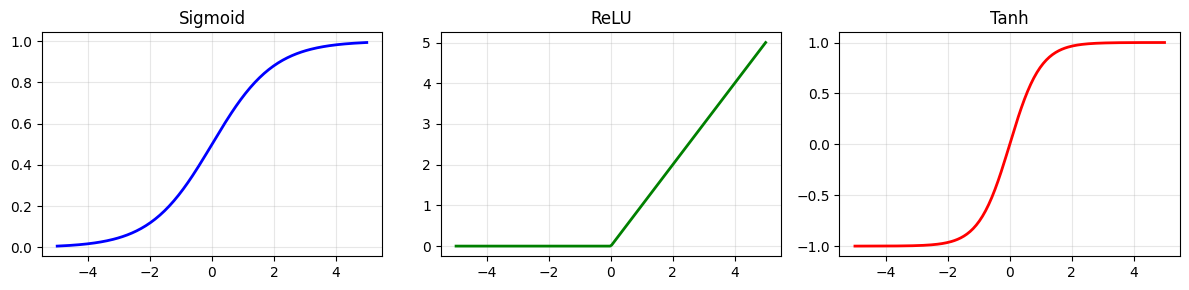

In [6]:
x = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(x, 1/(1+np.exp(-x)), color='blue', lw=2)
axes[0].set_title('Sigmoid'); axes[0].grid(True, alpha=0.3)

axes[1].plot(x, np.maximum(0,x), color='green', lw=2)
axes[1].set_title('ReLU'); axes[1].grid(True, alpha=0.3)

axes[2].plot(x, np.tanh(x), color='red', lw=2)
axes[2].set_title('Tanh'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Neural Networks

A neural network is a stack of layers. Each layer takes the output of the previous one and passes it through weights, bias and activation. The network learns by adjusting weights to reduce the loss.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Test accuracy: 83.0 %


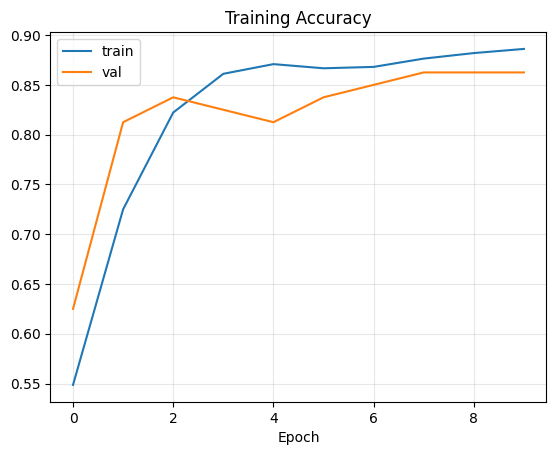

In [7]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(10,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

h = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

_, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', round(acc*100, 2), '%')

plt.plot(h.history['accuracy'], label='train')
plt.plot(h.history['val_accuracy'], label='val')
plt.title('Training Accuracy')
plt.xlabel('Epoch'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Backpropagation

Backpropagation is how the network learns. After each forward pass we compute how wrong the prediction was (loss), then go backwards through the network computing gradients using the chain rule, and update the weights using gradient descent.

Learned w = 1.8463  (should be ~2.0)
Final loss = 0.034290


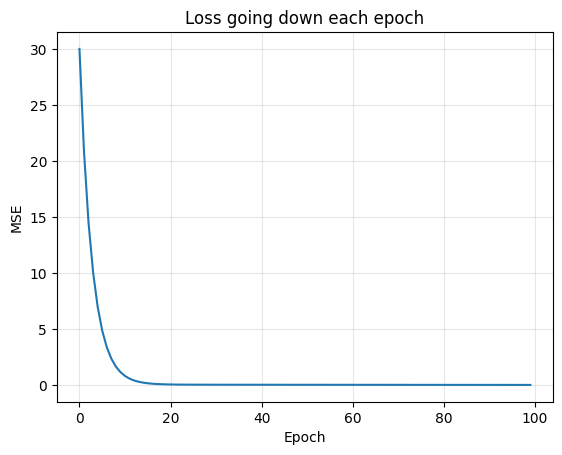

In [8]:
# simple 1-weight example to show backprop manually
X_bp = np.array([[1.0],[2.0],[3.0],[4.0]])
y_bp = np.array([[2.0],[4.0],[6.0],[8.0]])

w, b, lr = 0.0, 0.0, 0.01
losses = []

for _ in range(100):
    pred = X_bp * w + b
    loss = np.mean((pred - y_bp)**2)
    losses.append(loss)
    dw = np.mean(2 * (pred - y_bp) * X_bp)
    db = np.mean(2 * (pred - y_bp))
    w -= lr * dw
    b -= lr * db

print(f'Learned w = {w:.4f}  (should be ~2.0)')
print(f'Final loss = {losses[-1]:.6f}')

plt.plot(losses)
plt.title('Loss going down each epoch')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.show()

# ANN from Scratch

Building a two-layer neural network using only NumPy to solve the XOR problem. XOR cannot be solved by a single perceptron — we need at least one hidden layer.

XOR results:
  [0 0] -> predicted 0, actual 0
  [0 1] -> predicted 1, actual 1
  [1 0] -> predicted 1, actual 1
  [1 1] -> predicted 0, actual 0


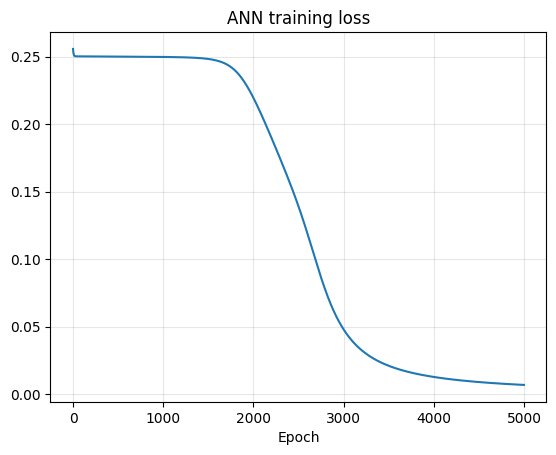

In [9]:
np.random.seed(42)

def sig(z):  return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def dsg(a):  return a * (1 - a)

W1 = np.random.randn(2, 4) * 0.5
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.5
b2 = np.zeros((1, 1))

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]],         dtype=float)

losses = []
for _ in range(5000):
    # forward
    A1 = sig(X_xor @ W1 + b1)
    A2 = sig(A1   @ W2 + b2)
    losses.append(np.mean((A2 - y_xor)**2))
    # backward
    d2 = (A2 - y_xor) * dsg(A2)
    d1 = (d2 @ W2.T)  * dsg(A1)
    W2 -= A1.T @ d2 / 4
    W1 -= X_xor.T @ d1 / 4

preds = (A2 > 0.5).astype(int)
print('XOR results:')
for xi, yi, pi in zip(X_xor.astype(int), y_xor.astype(int), preds):
    print(f'  {xi} -> predicted {pi[0]}, actual {yi[0]}')

plt.plot(losses)
plt.title('ANN training loss'); plt.xlabel('Epoch')
plt.grid(True, alpha=0.3); plt.show()

# Data Preprocessing

Raw data is usually on different scales which makes training unstable. We normalize it so each feature has mean 0 and standard deviation 1. We also split data into train and test sets so we can evaluate how well the model generalizes.

   age  salary      score  label
0   62   84223  28.691504      1
1   18   31052  67.726331      0
2   21   35741   6.303829      0
3   21   77368  55.564924      1
4   57  114275   0.924007      0
before mean: [3.99000e+01 7.29954e+04 5.07000e+01]
after  mean: [0. 0. 0.]
train: (160, 3)  test: (40, 3)


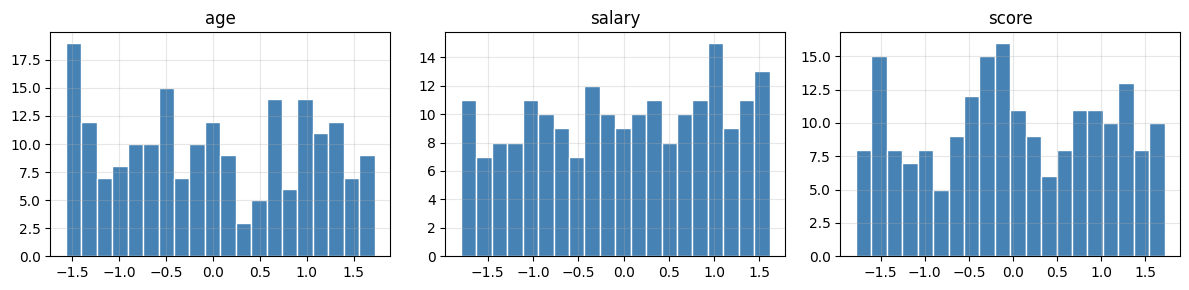

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(0)
df = pd.DataFrame({
    'age':    np.random.randint(18, 65, 200),
    'salary': np.random.randint(20000, 120000, 200),
    'score':  np.random.uniform(0, 100, 200),
    'label':  np.random.randint(0, 2, 200)
})

print(df.head())

X = df[['age','salary','score']].values
y = df['label'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('before mean:', X.mean(axis=0).round(1))
print('after  mean:', X_scaled.mean(axis=0).round(3))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'train: {X_train.shape}  test: {X_test.shape}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, name in enumerate(['age','salary','score']):
    axes[i].hist(X_scaled[:,i], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(name); axes[i].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Convolutional Neural Networks

CNNs are designed for image data. A convolutional layer slides a small filter across the image and detects features like edges and shapes. MaxPooling reduces the spatial size while keeping the most important information. Stacking these layers lets the network learn increasingly complex features.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


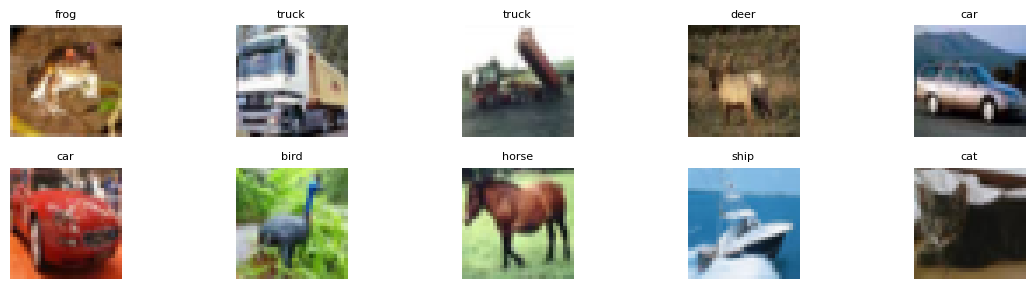

In [11]:
(X_tr, y_tr), (X_te, y_te) = keras.datasets.cifar10.load_data()
X_tr, X_te = X_tr / 255.0, X_te / 255.0

names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_tr[i])
    plt.title(names[y_tr[i][0]], fontsize=8)
    plt.axis('off')
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 85ms/step - accuracy: 0.4111 - loss: 1.6032 - val_accuracy: 0.5122 - val_loss: 1.3539
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.5566 - loss: 1.2496 - val_accuracy: 0.5834 - val_loss: 1.1592
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 86ms/step - accuracy: 0.6166 - loss: 1.0851 - val_accuracy: 0.6450 - val_loss: 1.0322
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.6531 - loss: 0.9836 - val_accuracy: 0.6536 - val_loss: 0.9921
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.6831 - loss: 0.9041 - val_accuracy: 0.6718 - val_loss: 0.9542
test accuracy: 64.59 %


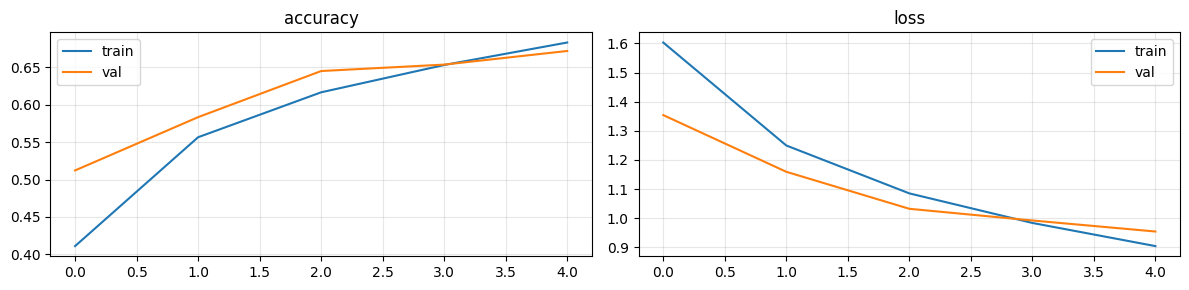

In [12]:
cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

h = cnn.fit(X_tr, y_tr, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

_, acc = cnn.evaluate(X_te, y_te, verbose=0)
print('test accuracy:', round(acc*100, 2), '%')

plt.figure(figsize=(12,3))
plt.subplot(1,2,1)
plt.plot(h.history['accuracy'], label='train')
plt.plot(h.history['val_accuracy'], label='val')
plt.title('accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(h.history['loss'], label='train')
plt.plot(h.history['val_loss'], label='val')
plt.title('loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Image Augmentation

When the training dataset is small, the model tends to overfit — it memorizes training examples instead of learning general patterns. Augmentation randomly transforms images during training so the model sees slightly different versions each time.

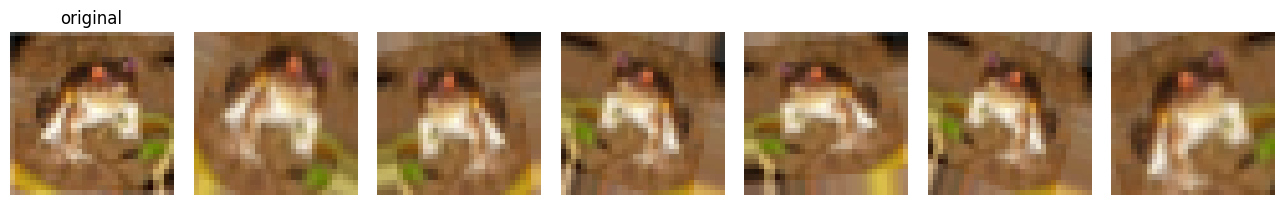

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1
)

sample = X_tr[:1]
plt.figure(figsize=(13, 2))
plt.subplot(1,7,1); plt.imshow(sample[0]); plt.title('original'); plt.axis('off')
i = 2
for batch in datagen.flow(sample, batch_size=1):
    plt.subplot(1,7,i); plt.imshow(batch[0]); plt.axis('off')
    i += 1
    if i > 7: break
plt.tight_layout(); plt.show()

# Pretrained Models and Transfer Learning

Training a CNN from scratch needs a lot of data and time. Transfer learning lets us reuse a model that was already trained on a large dataset like ImageNet. We freeze the base model weights and only train a small classification head on top for our specific task.

In [15]:
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(input_shape=(96,96,3), include_top=False, weights='imagenet')
base.trainable = False

model_tl = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_tl.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_tl.summary()

X_tr_r = tf.image.resize(X_tr[:3000], (96,96)).numpy()
X_te_r = tf.image.resize(X_te[:500],  (96,96)).numpy()

h_tl = model_tl.fit(X_tr_r, y_tr[:3000], epochs=3, batch_size=32, validation_split=0.1, verbose=1)

_, tl_acc = model_tl.evaluate(X_te_r, y_te[:500], verbose=0)
print('transfer learning accuracy:', round(tl_acc*100, 2), '%')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 82,634 (322.79 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 30s 295ms/step - accuracy: 0.4685 - loss: 1.5729 - val_accuracy: 0.6467 - val_loss: 1.0514
Epoch 2/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 226ms/step - accuracy: 0.6763 - loss: 0.9645 - val_accuracy: 0.6767 - val_loss: 0.9056
Epoch 3/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 236ms/step - accuracy: 0.7204 - loss: 0.7956 - val_accuracy: 0.7367 - val_loss: 0.7944
transfer learning accuracy: 70.8 %


# Fine-Tuning

After training the classification head, we can unfreeze the last few layers of the base model and retrain everything at a very low learning rate. This lets the pretrained features adapt slightly to our specific dataset.

In [16]:
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

model_tl.compile(optimizer=keras.optimizers.Adam(1e-5),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_tl.fit(X_tr_r, y_tr[:3000], epochs=3, batch_size=32, validation_split=0.1, verbose=1)

_, ft_acc = model_tl.evaluate(X_te_r, y_te[:500], verbose=0)
print('before fine-tuning:', round(tl_acc*100, 2), '%')
print('after  fine-tuning:', round(ft_acc*100, 2), '%')

Epoch 1/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 39s 355ms/step - accuracy: 0.5670 - loss: 1.2809 - val_accuracy: 0.7100 - val_loss: 0.8093
Epoch 2/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 28s 326ms/step - accuracy: 0.6452 - loss: 1.0483 - val_accuracy: 0.6933 - val_loss: 0.8495
Epoch 3/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 41s 325ms/step - accuracy: 0.6911 - loss: 0.9223 - val_accuracy: 0.6767 - val_loss: 0.8859
before fine-tuning: 70.8 %
after  fine-tuning: 72.2 %


# Object Detection

Object detection goes beyond classification — it finds where objects are in the image using bounding boxes. YOLO processes the entire image in one pass which makes it very fast. We use a pretrained YOLOv8 model here.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


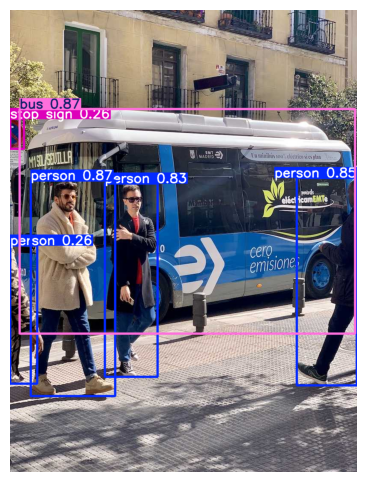

  bus: 87.3%
  person: 86.6%
  person: 85.3%
  person: 82.5%
  person: 26.1%
  stop sign: 25.5%


In [17]:
from ultralytics import YOLO

model_yolo = YOLO('yolov8n.pt')

results = model_yolo.predict(
    source='https://ultralytics.com/images/bus.jpg',
    save=False, verbose=False
)

plt.figure(figsize=(10,6))
plt.imshow(results[0].plot()[:,:,::-1])
plt.axis('off'); plt.show()

for box in results[0].boxes:
    name = results[0].names[int(box.cls[0])]
    conf = float(box.conf[0])
    print(f'  {name}: {conf*100:.1f}%')

# Semantic Segmentation

Semantic segmentation classifies every pixel in the image, not just the image as a whole. U-Net is a popular architecture for this. It has an encoder that compresses the image and a decoder that brings it back to the original size, with skip connections between matching layers.

In [18]:
def build_unet(input_shape=(64,64,3), num_classes=3):
    inp = keras.Input(shape=input_shape)

    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    bn = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

    u1 = layers.Conv2DTranspose(64, 2, strides=2)(bn)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    u2 = layers.Conv2DTranspose(32, 2, strides=2)(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)

    out = layers.Conv2D(num_classes, 1, activation='softmax')(c4)
    return keras.Model(inp, out)

unet = build_unet()
unet.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
unet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │        896 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │     32,832 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,792 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │      8,224 │ conv2d_6[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     18,464 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64, 3) │         99 │ conv2d_7[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 226,659 (885.39 KB)

 Trainable params: 226,659 (885.39 KB)

 Non-trainable params: 0 (0.00 B)

# MNIST — Handwritten Digit Recognition

MNIST has 70,000 grayscale images of handwritten digits 0 through 9. We build two models — a simple ANN using dense layers and a CNN using convolutional layers — and compare their performance.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
train: (60000, 28, 28)   test: (10000, 28, 28)


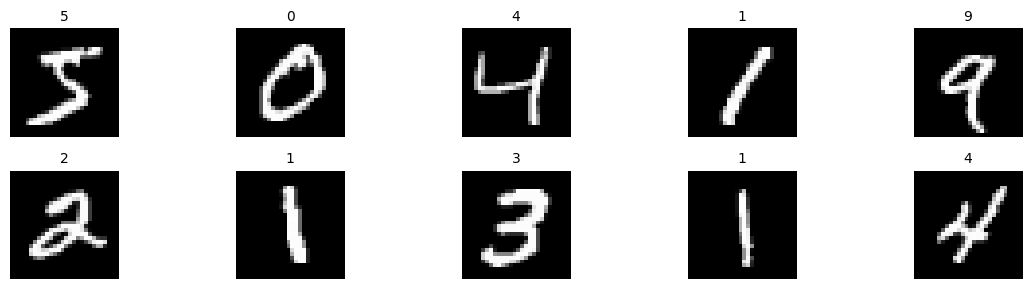

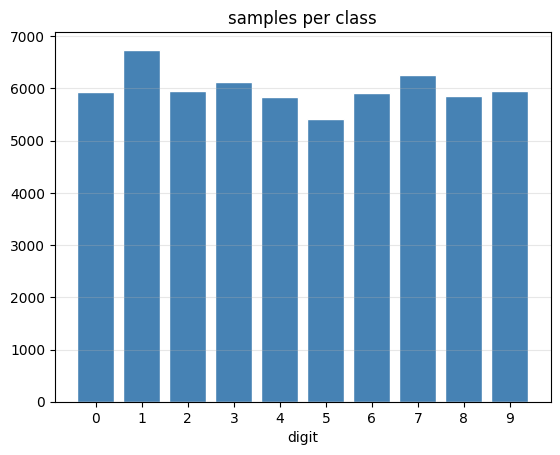

In [19]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

print('train:', X_train.shape, '  test:', X_test.shape)

plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(str(y_train[i]), fontsize=10)
    plt.axis('off')
plt.tight_layout(); plt.show()

vals, counts = np.unique(y_train, return_counts=True)
plt.bar(vals, counts, color='steelblue', edgecolor='white')
plt.title('samples per class'); plt.xlabel('digit')
plt.xticks(range(10)); plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [21]:
# ANN
ann = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64,  activation='relu'),
    layers.Dense(10,  activation='softmax')
], name='ANN')

ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.summary()

h_ann = ann.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
_, ann_acc = ann.evaluate(X_test, y_test, verbose=0)
print('ANN accuracy:', round(ann_acc*100, 2), '%')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8781 - loss: 0.4181 - val_accuracy: 0.9597 - val_loss: 0.1479
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9452 - loss: 0.1845 - val_accuracy: 0.9703 - val_loss: 0.1060
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9586 - loss: 0.1387 - val_accuracy: 0.9725 - val_loss: 0.0916
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9667 - loss: 0.1090 - val_accuracy: 0.9752 - val_loss: 0.0805
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9711 - loss: 0.0929 - val_accuracy: 0.9768 - val_loss: 0.0761
ANN accuracy: 97.39 %


In [20]:
# CNN
X_tr_c = X_train.reshape(-1, 28, 28, 1)
X_te_c = X_test.reshape(-1,  28, 28, 1)

cnn_m = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='CNN')

cnn_m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_m.summary()

h_cnn = cnn_m.fit(X_tr_c, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
_, cnn_acc = cnn_m.evaluate(X_te_c, y_test, verbose=0)
print('CNN accuracy:', round(cnn_acc*100, 2), '%')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 106ms/step - accuracy: 0.8989 - loss: 0.3324 - val_accuracy: 0.9822 - val_loss: 0.0615
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.9726 - loss: 0.0932 - val_accuracy: 0.9867 - val_loss: 0.0451
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9808 - loss: 0.0651 - val_accuracy: 0.9878 - val_loss: 0.0414
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 109ms/step - accuracy: 0.9845 - loss: 0.0510 - val_accuracy: 0.9898 - val_loss: 0.0353
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.9869 - loss: 0.0434 - val_accuracy: 0.9897 - val_loss: 0.0354
CNN accuracy: 99.03 %


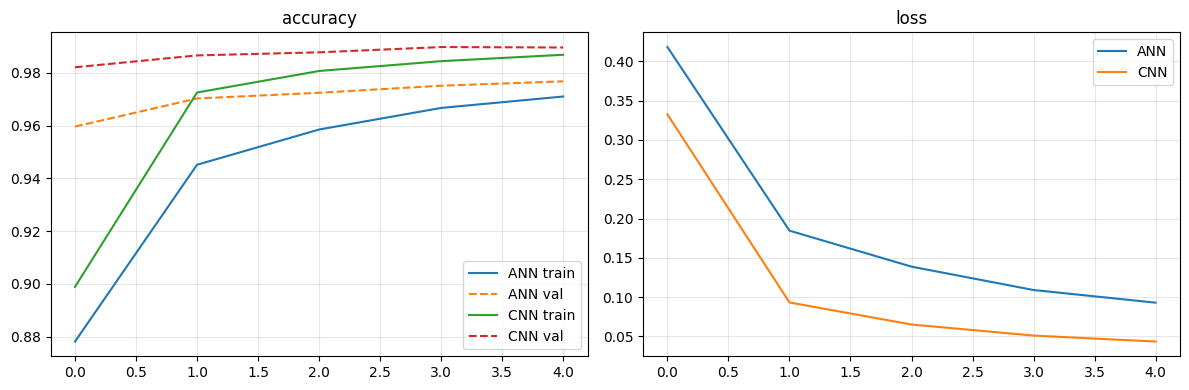

In [22]:
# training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(h_ann.history['accuracy'],     label='ANN train')
axes[0].plot(h_ann.history['val_accuracy'], label='ANN val',   ls='--')
axes[0].plot(h_cnn.history['accuracy'],     label='CNN train')
axes[0].plot(h_cnn.history['val_accuracy'], label='CNN val',   ls='--')
axes[0].set_title('accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(h_ann.history['loss'], label='ANN')
axes[1].plot(h_cnn.history['loss'], label='CNN')
axes[1].set_title('loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

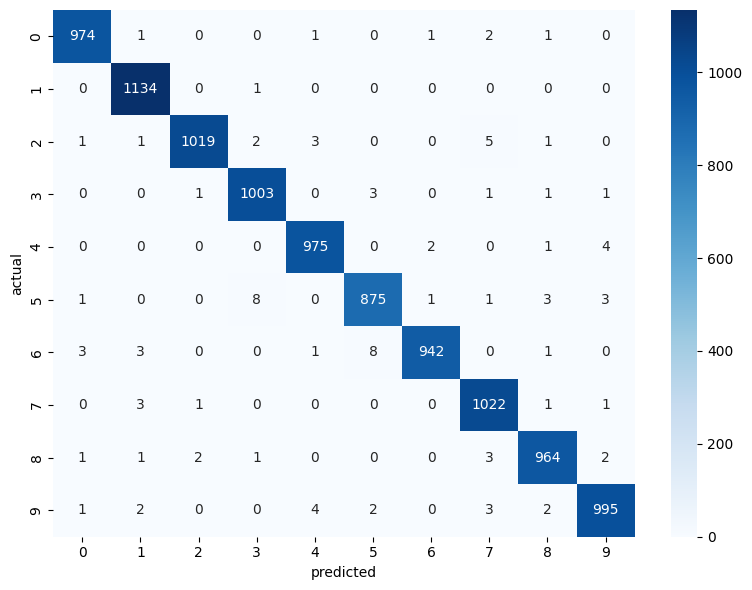

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.98       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [23]:
# confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(cnn_m.predict(X_te_c, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.ylabel('actual'); plt.xlabel('predicted')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred))

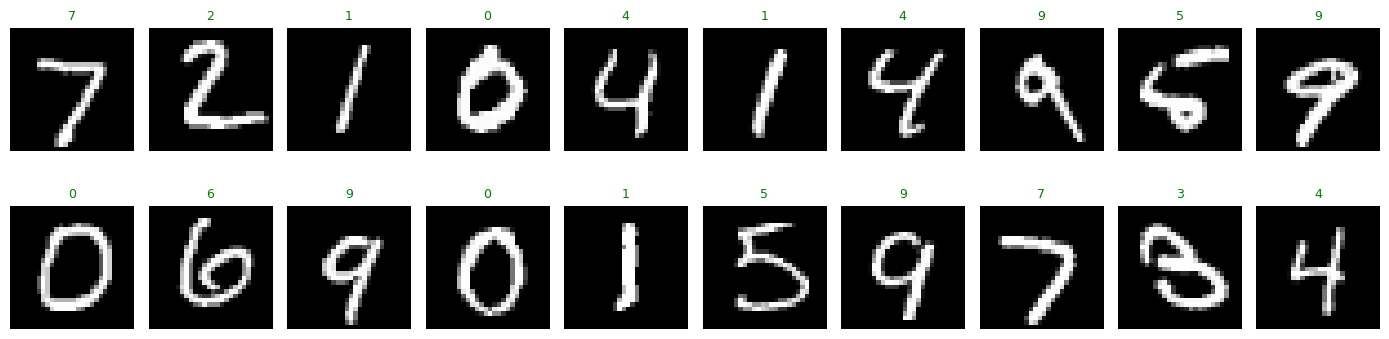

ANN: 97.39 %
CNN: 99.03 %


In [24]:
# sample predictions
preds = np.argmax(cnn_m.predict(X_te_c[:20], verbose=0), axis=1)

plt.figure(figsize=(14, 4))
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i], cmap='gray')
    color = 'green' if preds[i] == y_test[i] else 'red'
    plt.title(str(preds[i]), color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout(); plt.show()

print('ANN:', round(ann_acc*100, 2), '%')
print('CNN:', round(cnn_acc*100, 2), '%')